# Exercises

There are three exercises in this notebook:

1. Use the cross-validation method to test the linear regression with different $\alpha$ values, at least three.
2. Implement a SGD method that will train the Lasso regression for 10 epochs.
3. Extend the Fisher's classifier to work with two features. Use the class as the $y$.

In [674]:
# imports
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import LeaveOneOut
from sklearn.linear_model import Lasso
from sklearn.datasets import load_iris

## 1. Ridge regression

In [675]:
# x, y, identity and alpha values
x_a = np.array([188, 181, 197, 168, 167, 187, 178, 194, 140, 176, 168, 192, 173, 142, 176]).reshape(-1, 1)
y = np.array([141, 106, 149, 59, 79, 136, 65, 136, 52, 87, 115, 140, 82, 69, 121]).reshape(-1, 1)
x = np.asmatrix(np.c_[np.ones((15,1)),x_a])

I = np.identity(2)
alpha = [0.08, 0.16, 0.32, 0.64]

In [676]:
# calculate weights for different alpha
w = np.empty([4, 2])

for i in range(4):
  t = np.linalg.inv(x.T @ x + alpha[i] * I) @ x.T @ y
  w[i] = t.reshape(1, 2)

In [677]:
# display weights per alpha value
for i in range(4):
  print(f"alpha={alpha[i]}    weights:{w[i]}")

alpha=0.08    weights:[-111.48463211    1.22504311]
alpha=0.16    weights:[-80.56336423   1.04999642]
alpha=0.32    weights:[-51.8179917    0.88726747]
alpha=0.64    weights:[-30.23822343   0.76510309]


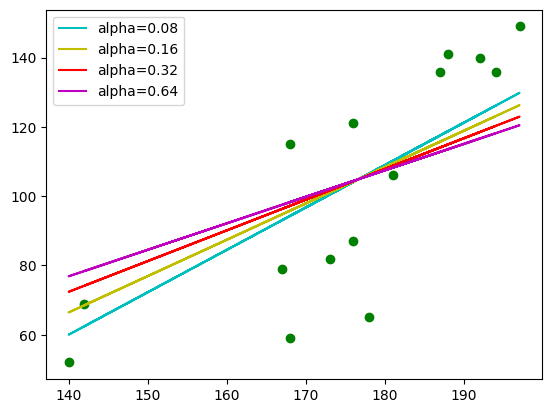

In [678]:
# linear regression comparison on plots per alpha value
def reg_predict(inputs, w, b):
    results = []
    for inp in inputs:
        results.append(inp * w + b)
    return results

plt.scatter(x_a, y, color='g')

colors = ['c', 'y', 'r', 'm']

for i, a in enumerate(alpha):
    m = np.asarray(w[i]).ravel()
    plt.plot(x_a, reg_predict(x_a.flatten(), m[1], m[0]), color=colors[i], label=f'alpha={a}')

plt.legend(loc='best')
plt.show()

In [679]:
# linear regression accuracy comparison per alpha value
# Leave One Out Cross-Validation
cv_results = {}

for a in alpha:
    errors = []

    for train_index, test_index in LeaveOneOut().split(x_a):
        X_train, X_test = x[train_index], x[test_index]
        y_train, y_test = y[train_index], y[test_index]

        w_cv = np.linalg.inv(X_train.T @ X_train + a * I) @ X_train.T @ y_train

        y_pred = X_test @ w_cv

        errors.append((y_test[0][0] - y_pred[0][0])**2)

    cv_results[a] = np.mean(errors)

for a, mse in cv_results.items():
    print(f"alpha={a}    mean_square_error={mse:.2f}")


alpha=0.08    mean_square_error=494.26
alpha=0.16    mean_square_error=546.66
alpha=0.32    mean_square_error=610.30
alpha=0.64    mean_square_error=665.27


## 2. Lasso regression

In [680]:
# stochastic gradient descent
def sgd(X, y, w, alpha, lr):
    prediction = X @ w
    error = prediction - y

    grad_err = X.T @ error

    grad_l1 = alpha * np.sign(w)
    grad_l1[0] = 0

    total_grad = grad_err + grad_l1

    # update weights
    return w - lr * total_grad

In [681]:
# x, y, and training values
x_a = np.array([188, 181, 197, 168, 167, 187, 178, 194, 140, 176, 168, 192, 173, 142, 176]).reshape(-1, 1).reshape(15,1)
y = np.array([141, 106, 149, 59, 79, 136, 65, 136, 52, 87, 115, 140, 82, 69, 121]).reshape(-1, 1).reshape(15,1)

x = np.asmatrix(np.c_[np.ones((15,1)),x_a])

I = np.identity(2)

alpha = 0.1
learning_rate = 0.000001
epochs = 10
w = np.zeros((2, 1))

In [682]:
# sklearn Lasso
lasso_sk = Lasso(alpha=0.1/15, fit_intercept=False)
lasso_sk.fit(x_a, y)

# training
for epoch in range(epochs):
    indices = np.random.permutation(15)
    for i in indices:
        x_i = x[i : i+1]
        y_i = y[i : i+1]
        w = sgd(x_i, y_i, w, alpha, learning_rate)

In [683]:
# weights comparison
print(f"My SGD + Lasso: {w[1].item():.5f}")
print(f"Sklearn Lasso: {lasso_sk.coef_.item():.5f}")

My SGD + Lasso: 0.58805
Sklearn Lasso: 0.59392


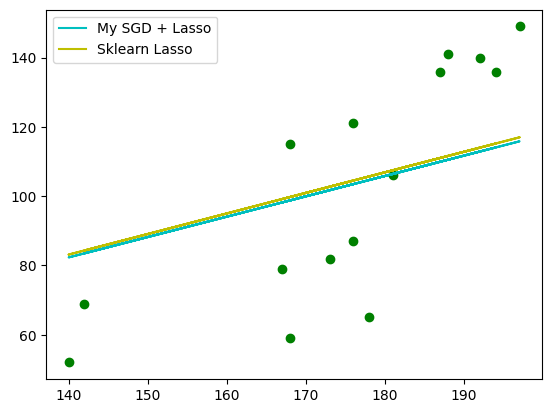

In [684]:
# comparison on plots

y_my = x_a * w[1].item()
y_sk = x_a * lasso_sk.coef_[0]

plt.scatter(x_a, y, color='g')

plt.plot(x_a, y_my, color='c', label='My SGD + Lasso')
plt.plot(x_a, y_sk, color='y', label='Sklearn Lasso')

plt.legend(loc='best')
plt.show()

## 3. Fisher's classifier

Fisher classification on Iris data. Species 1 and 2 are two classes.

Obtained model classifies flower with the folowing features: [6.45, 2.85, 4.25, 1.25].

In [685]:
# load data
iris = load_iris()
X = iris.data
y = iris.target

# filter classes
X = X[(y == 1) | (y == 2)]
y = y[(y == 1) | (y == 2)]

In [686]:
# class means
mean1 = np.mean(X[y == 1], axis=0)
mean2 = np.mean(X[y == 2], axis=0)

# scatter
Sw = np.dot(( X[y == 1] - mean1 ).T , ( X[y == 1] - mean1 ) ) + np.dot(( X[y == 2] - mean2 ).T , ( X[y == 2] - mean2 ) )

w = np.dot( np.linalg.inv( Sw ) , ( mean2 - mean1 ) )

# decision treshold
threshold = (mean1 @ w + mean2 @ w) / 2

In [687]:
# new flower classification
new_flower = np.array([6.45, 2.85, 4.25, 1.25])
new_projection = new_flower @ w

if new_projection < threshold:
  prediction = 1
else:
  prediction = 2

print(f"threshold: {threshold.item():.4f}")
print(f"new flower: {new_projection.item():.4f}")
print(f"predicted class: {prediction}")

threshold: 0.1700
new flower: 0.0640
predicted class: 1


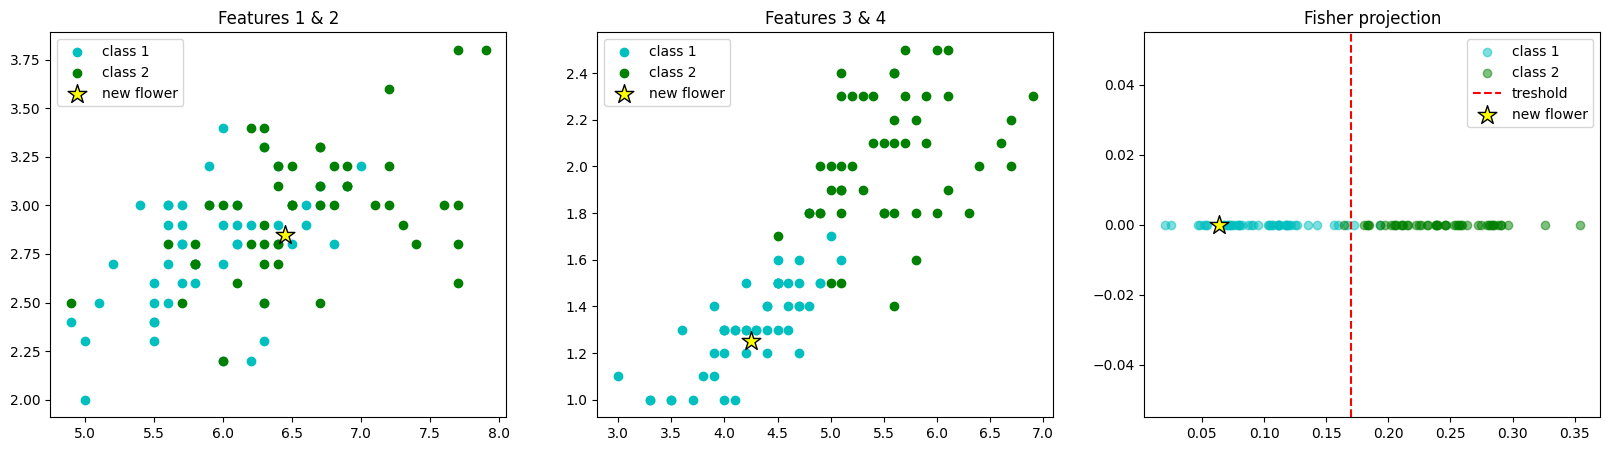

In [688]:
# new flower on the plots
plt.figure(figsize=(20, 5))

# features of class 1 vs 2
plt.subplot(1, 3, 1)
plt.scatter(X[y==1][:, 0], X[y==1][:, 1], c='c', label='class 1')
plt.scatter(X[y==2][:, 0], X[y==2][:, 1], c='g', label='class 2')
plt.scatter(new_flower[0], new_flower[1], color='yellow',  marker='*', s=200, label='new flower', edgecolors='black')
plt.title("Features 1 & 2")
plt.legend()

plt.subplot(1, 3, 2)
plt.scatter(X[y==1][:, 2], X[y==1][:, 3], c='c', label='class 1')
plt.scatter(X[y==2][:, 2], X[y==2][:, 3], c='g', label='class 2')
plt.scatter(new_flower[2], new_flower[3], color='yellow',  marker='*', s=200, label='new flower', edgecolors='black')
plt.title("Features 3 & 4")
plt.legend()

# fisher projection and decision treshold
plt.subplot(1, 3, 3)
plt.scatter(projection[y==1], np.zeros(50), c='c', alpha=0.5, label='class 1')
plt.scatter(projection[y==2], np.zeros(50), c='g', alpha=0.5, label='class 2')
plt.axvline(threshold, color='r', linestyle='--', label='treshold')
plt.scatter(new_projection, 0, color='yellow', marker='*', s=200, label='new flower', edgecolors='black')
plt.title("Fisher projection")
plt.legend()

plt.show()